In [26]:
# 프로핏 라이브러리 탑재
from prophet import Prophet

In [27]:
# 판다스 라이브러리, request 모듈 탑재
import pandas as pd
import requests
from io import StringIO

# 페이지 번호를 제외한 주소 저장
new_url = "https://finance.naver.com/item/sise_day.naver?code=252670&page="

# 헤더 정보 설정하기
my_headers = {'user-agent' : 'Mozilla/5.0'}

In [28]:
# 데이터를 축적할 데이터프레임 생성 
all_tables_year = pd.DataFrame()

# 페이지 증가용 반복문
for page_number in range(1, 100):

    # 페이지 본호 추가한 주소 완성
    full_url = new_url + str(page_number)

    # 주소 확인하기
    print(f'{page_number} 번째 페이지 읽어오기({full_url})')

    # HTTP 요청 전송 후 응답 받아오기
    page = requests.get(full_url, headers=my_headers)
    
    # 테이블 추출
    table = pd.read_html(StringIO(page.text))[0]

    # 수행할 내용 확인
    print(f'전체 {len(all_tables_year.index)} 줄에 {len(table.index)}줄 추가')

    # 데이터 축적용 데이터프레임에 테이블 추가
    all_tables_year = pd.concat([all_tables_year, table])

1 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=1)
전체 0 줄에 15줄 추가
2 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=2)
전체 15 줄에 15줄 추가
3 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=3)
전체 30 줄에 15줄 추가
4 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=4)
전체 45 줄에 15줄 추가
5 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=5)
전체 60 줄에 15줄 추가
6 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=6)
전체 75 줄에 15줄 추가
7 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=7)
전체 90 줄에 15줄 추가
8 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=8)
전체 105 줄에 15줄 추가
9 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=9)
전체 120 줄에 15줄 추가
10 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=252670&page=10)
전체 135 줄에 15줄 추가
11 번째 페이지 읽어오기(https://finance.naver

In [30]:
# 결손치 제거
all_tables_year.dropna(inplace=True)

# 열 이름 영문으로 변경 
all_tables_year.rename(columns={'날짜' : 'ds'}, inplace=True)

# 중위값 열 추가
all_tables_year['y'] = all_tables_year['고가'] - ((all_tables_year['고가'] - all_tables_year['저가']) /2)

all_tables_year

,ds,종가,전일비,시가,고가,저가,거래량,y
1,2026.05.20,128.0,상승 5,122.0,132.0,121.0,1.191293e+10,126.5
2,2026.05.19,123.0,상승 7,119.0,128.0,119.0,1.007788e+10,123.5
3,2026.05.18,116.0,하락 2,120.0,129.0,112.0,1.633917e+10,120.5
4,2026.05.15,118.0,상승 14,105.0,121.0,102.0,1.077240e+10,111.5
5,2026.05.14,104.0,하락 4,108.0,109.0,103.0,7.453149e+09,106.0
...,...,...,...,...,...,...,...,...
9,2022.05.09,2715.0,상승 55,2690.0,2725.0,2660.0,1.523577e+08,2692.5
10,2022.05.06,2660.0,상승 70,2650.0,2680.0,2645.0,1.333287e+08,2662.5
11,2022.05.04,2590.0,하락 10,2575.0,2610.0,2555.0,1.106375e+08,2582.5
12,2022.05.03,2600.0,상승 15,2595.0,2605.0,2550.0,1.579115e+08,2577.5


In [31]:
# 최종 입력 데이터 프레임 준비하기 

# 학습 대상 데이터 프레임 생성
df = pd.DataFrame()

# 필요한 열만 추출하여 저장
df = all_tables_year[['ds', 'y']]

# 데이터프레임 정보 확인하기
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 1 to 13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      990 non-null    object 
 1   y       990 non-null    float64
dtypes: float64(1), object(1)
memory usage: 23.2+ KB


In [32]:
# 데이터 학습하기

# 프로핏 모델 객체 만들기
m = Prophet()

# 데이터 프레임 학습하기
m.fit(df)

14:36:07 - cmdstanpy - INFO - Chain [1] start processing
14:36:07 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
# 예측 결과 저장용 데이터 프레임 준비하기

# 예측 데이터프레임 준비하기
future = m.make_future_dataframe(periods=1000)

# 끝부분 확인하기
future.tail()

,ds
1985,2029-02-09
1986,2029-02-10
1987,2029-02-11
1988,2029-02-12
1989,2029-02-13


In [35]:
# 예측하기
forecast = m.predict(future)

# 예측 결과 끝부분 확인하기
forecast[['ds' , 'yhat', 'yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1985,2029-02-09,-5038.389520,-9918.776030,-362.154790
1986,2029-02-10,-5177.054380,-10042.376501,-569.273345
1987,2029-02-11,-5185.942723,-10111.573614,-561.243793
1988,2029-02-12,-5057.024595,-9983.649530,-429.075272
1989,2029-02-13,-5073.479365,-9997.099974,-397.683231


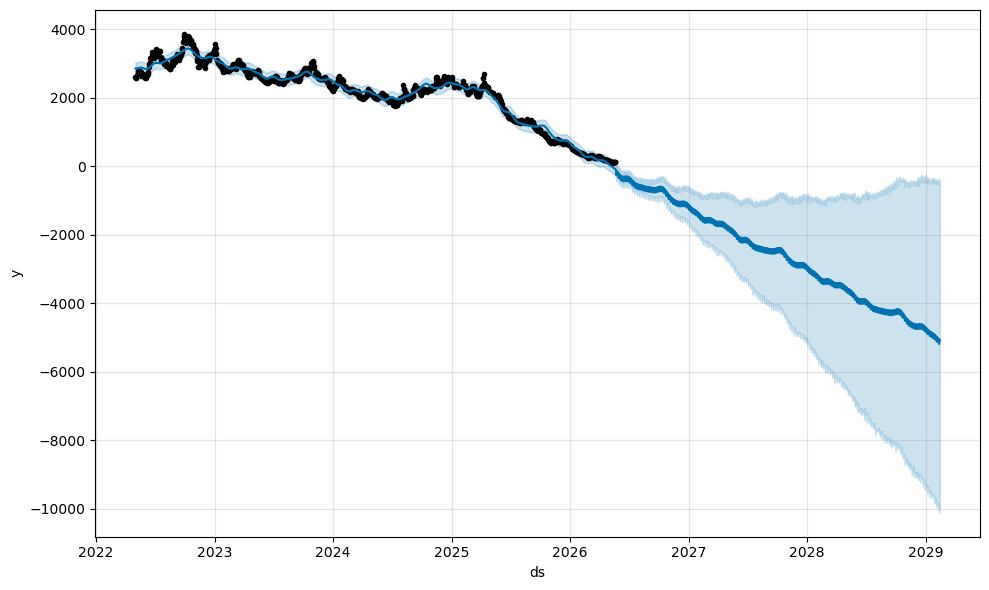

In [41]:
ㅈㅈ

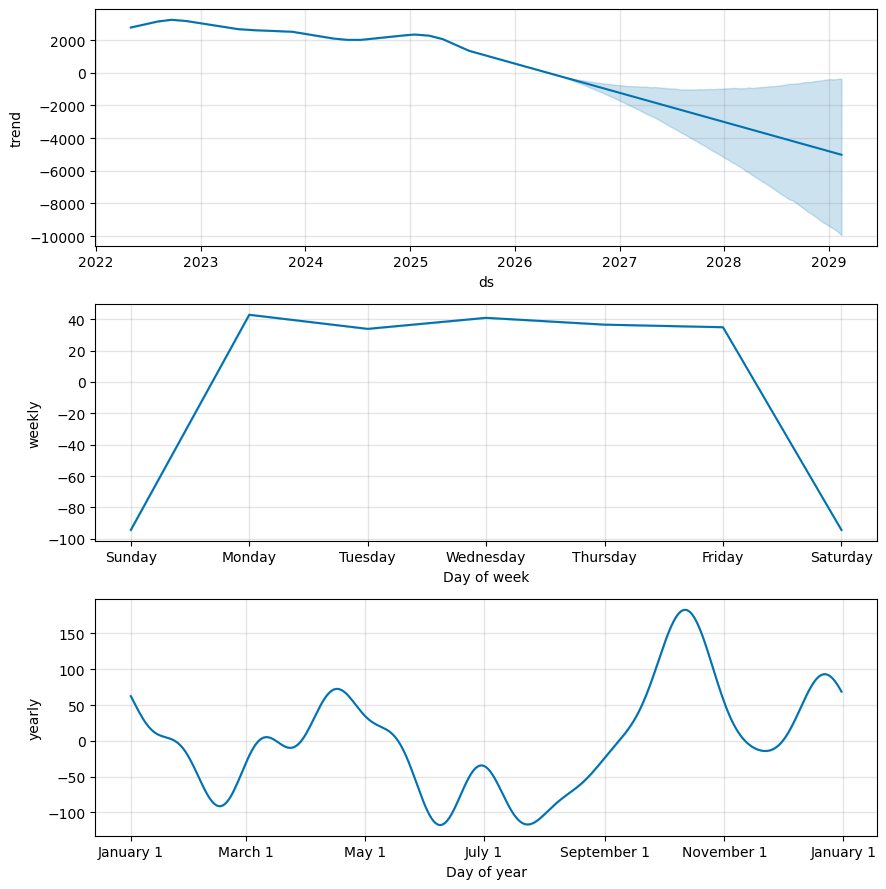

In [37]:
# 예측 컴포넌트 확인하기
fig2 = m.plot_components(forecast)

C:\Users\USER\AppData\Local\Temp\ipykernel_4632\4268506334.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ds'] = pd.to_datetime(df['ds'])
15:00:06 - cmdstanpy - INFO - Chain [1] start processing
15:00:06 - cmdstanpy - INFO - Chain [1] done processing


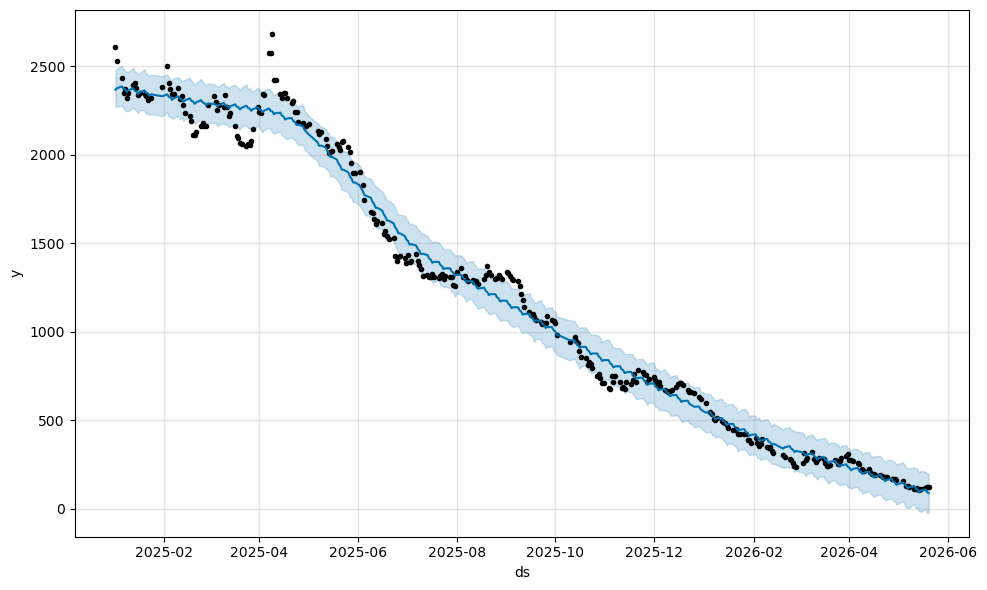

In [56]:
# 날짜형 변환
df['ds'] = pd.to_datetime(df['ds'])

# 특정 기간 데이터만 추출
df2 = df[df['ds'] > '2025-01-01']

# 모델 생성
m2 = Prophet()

# df2만 학습
m2.fit(df2)

# 예측 결과 시각화하기
fig3 = m2.plot(m2.predict(df2))

## 직접 풀어보기
- KAKAO 1년간 시세와 1년 후 예측 최댓값, 최소값

In [77]:
# 페이지 번호를 제외한 주소 저장
KAKAO_url = "https://finance.naver.com/item/sise_day.naver?code=035720&page="

# 헤더 정보 설정하기
my_headers = {'user-agent' : 'Mozilla/5.0'}

# 데이터를 축적할 데이터프레임 생성 
all_tables_year = pd.DataFrame()

# 페이지 증가용 반복문
for page_number in range(1, 100):

    # 페이지 본호 추가한 주소 완성
    full_url = KAKAO_url + str(page_number)

    # 주소 확인하기
    print(f'{page_number} 번째 페이지 읽어오기({full_url})')

    # HTTP 요청 전송 후 응답 받아오기
    page = requests.get(full_url, headers=my_headers)
    
    # 테이블 추출
    table = pd.read_html(StringIO(page.text))[0]

    # 수행할 내용 확인
    print(f'전체 {len(all_tables_year.index)} 줄에 {len(table.index)}줄 추가')

    # 데이터 축적용 데이터프레임에 테이블 추가
    all_tables_year = pd.concat([all_tables_year, table])

    # 결손치 제거
all_tables_year.dropna(inplace=True)

# 열 이름 영문으로 변경 
all_tables_year.rename(columns={'날짜' : 'ds'}, inplace=True)

# 중위값 열 추가
all_tables_year['y'] = all_tables_year['고가'] - ((all_tables_year['고가'] - all_tables_year['저가']) /2)


# 최종 입력 데이터 프레임 준비하기 

# 학습 대상 데이터 프레임 생성
df = pd.DataFrame()

# 필요한 열만 추출하여 저장
df = all_tables_year[['ds', 'y']]


# 데이터 학습하기

# 프로핏 모델 객체 만들기
m = Prophet()

# 데이터 프레임 학습하기
m.fit(df)

# 예측 결과 저장용 데이터 프레임 준비하기

# 예측 데이터프레임 준비하기
future = m.make_future_dataframe(periods=500)

# 예측하기
forecast = m.predict(future)

# 예측 결과 끝부분 확인하기
forecast[['ds' , 'yhat', 'yhat_lower','yhat_upper']].tail()



1 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=1)
전체 0 줄에 15줄 추가
2 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=2)
전체 15 줄에 15줄 추가
3 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=3)
전체 30 줄에 15줄 추가
4 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=4)
전체 45 줄에 15줄 추가
5 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=5)
전체 60 줄에 15줄 추가
6 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=6)
전체 75 줄에 15줄 추가
7 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=7)
전체 90 줄에 15줄 추가
8 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=8)
전체 105 줄에 15줄 추가
9 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=9)
전체 120 줄에 15줄 추가
10 번째 페이지 읽어오기(https://finance.naver.com/item/sise_day.naver?code=035720&page=10)
전체 135 줄에 15줄 추가
11 번째 페이지 읽어오기(https://finance.naver

15:33:23 - cmdstanpy - INFO - Chain [1] start processing
15:33:23 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
1485,2027-09-28,16973.141820,-37695.208713,74533.595579
1486,2027-09-29,16379.244071,-38828.127243,71896.980604
1487,2027-09-30,16154.842817,-38073.148587,71705.142155
1488,2027-10-01,15800.558670,-39197.198683,71704.969865
1489,2027-10-02,14660.370304,-39783.868439,68700.590082


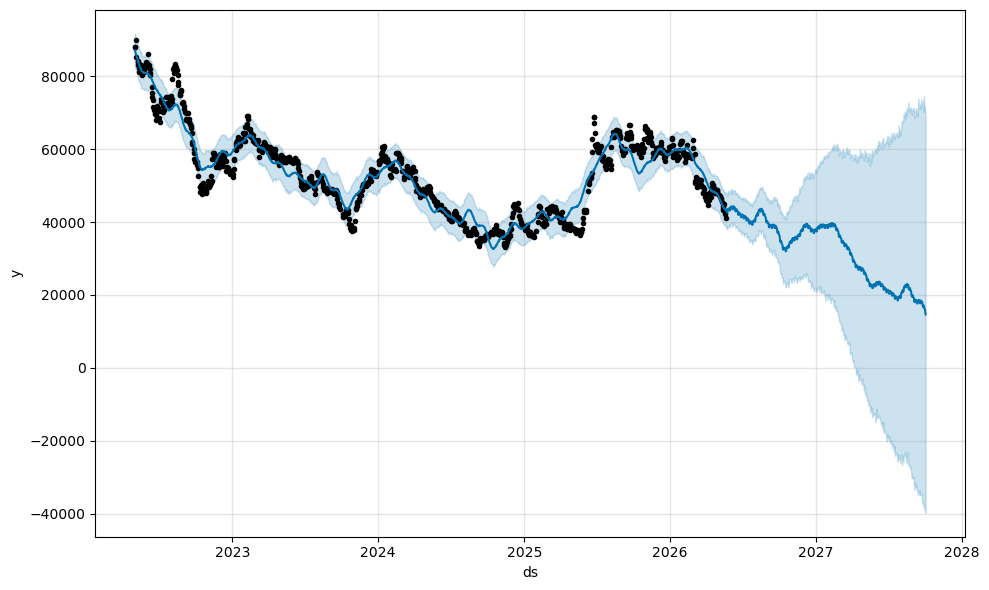

In [78]:
# 단순 그래프로 시각화하기

# 예측 결과 시각화하기 
fig1 = m.plot(forecast)

In [68]:
import matplotlib.pyplot as plt

# CSV 파일 읽기
df = pd.read_csv(r"C:\data/owid-covid-data_download.csv")

# 필요한 컬럼만 선택
selected_columns = ['iso_code', 'location', 'date', 'total_cases', 'population']
revised_df = df[selected_columns]

# 한국 데이터만 필터링
kor_df = revised_df[revised_df.location == 'South Korea']

# date와 total_cases 컬럼만 추출
KOR_covid_df = kor_df[['date', 'total_cases']].copy()  # .copy() 추가해서 경고 방지

# Prophet에 필요한 컬럼명으로 변경 (ds, y)
KOR_covid_df = KOR_covid_df.rename(columns={'date': 'ds', 'total_cases': 'y'})

# 결측치 제거
KOR_covid_df = KOR_covid_df.dropna()

# 날짜를 datetime 형식으로 변환
KOR_covid_df['ds'] = pd.to_datetime(KOR_covid_df['ds'])

# 데이터 확인
print(KOR_covid_df.head())
print(f"\n데이터 수: {len(KOR_covid_df)}개")
print(f"기간: {KOR_covid_df['ds'].min()} ~ {KOR_covid_df['ds'].max()}")

               ds    y
359238 2020-01-05  0.0
359239 2020-01-06  0.0
359240 2020-01-07  0.0
359241 2020-01-08  0.0
359242 2020-01-09  0.0

데이터 수: 1674개
기간: 2020-01-05 00:00:00 ~ 2024-08-04 00:00:00


15:26:23 - cmdstanpy - INFO - Chain [1] start processing
15:26:25 - cmdstanpy - INFO - Chain [1] done processing


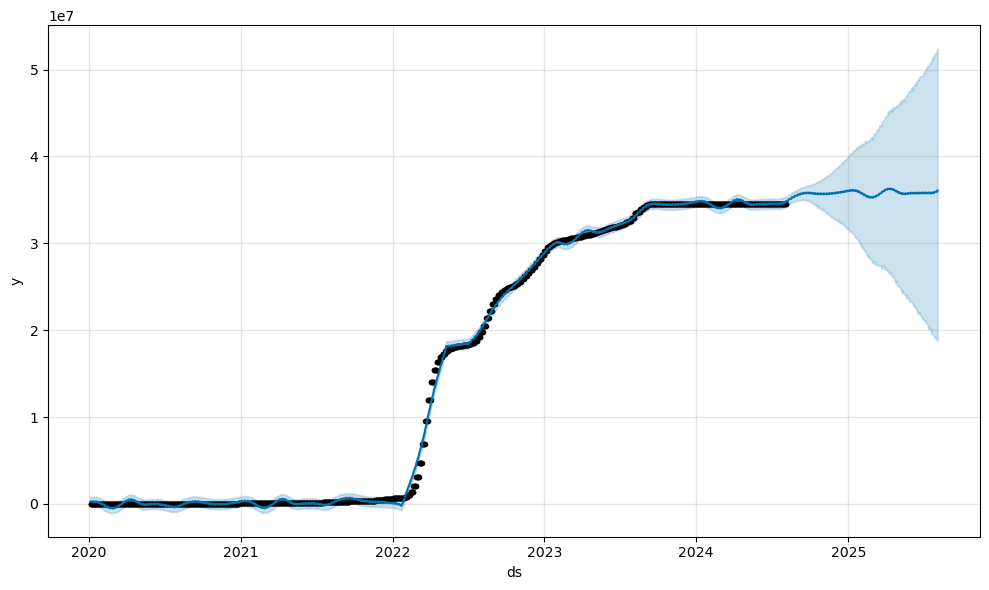

In [72]:
# Prophet 모델 생성 및 학습
m = Prophet()
m.fit(KOR_covid_df)

# 향후 1년(365일) 예측
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

# 예측 결과 시각화
fig = m.plot(forecast)
plt.show()
